In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import chi2_contingency
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mplcyberpunk
import seaborn as sns
import re

plt.style.use("cyberpunk")
pd.set_option('display.max_columns', None)

# The Source


## Sample Data


In [2]:
df = pd.read_csv('Telco.csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Profiling


In [3]:
profile = []
for col in df.columns:
    if df[col].nunique() < 10:
        profile.append(
            {
                'Column': col,
                'Data Type': df[col].dtypes,
                'Number of Unique Values': df[col].nunique(),
                'Values': df[col].unique().tolist()
            }
        )
    else:
        profile.append(
            {
                'Column': col,
                'Data Type': df[col].dtypes,
                'Number of Unique Values': df[col].nunique(),
                'Values': f'{df[col].iloc[42]} (sample)'
            }
        )

profile_df = pd.DataFrame(profile)
profile_df

,Column,Data Type,Number of Unique Values,Values
0,customerID,object,7043,9867-JCZSP (sample)
1,gender,object,2,"[Female, Male]"
2,SeniorCitizen,int64,2,"[0, 1]"
3,Partner,object,2,"[Yes, No]"
4,Dependents,object,2,"[No, Yes]"
5,tenure,int64,73,17 (sample)
6,PhoneService,object,2,"[No, Yes]"
7,MultipleLines,object,3,"[No phone service, No, Yes]"
8,InternetService,object,3,"[DSL, Fiber optic, No]"
9,OnlineSecurity,object,3,"[No, Yes, No internet service]"


# Data Quality Assessment


## **Validity**: Fixing TotalCharges


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.count()

customerID          7043
gender              7043
SeniorCitizen       7043
Partner             7043
Dependents          7043
tenure              7043
PhoneService        7043
MultipleLines       7043
InternetService     7043
OnlineSecurity      7043
OnlineBackup        7043
DeviceProtection    7043
TechSupport         7043
StreamingTV         7043
StreamingMovies     7043
Contract            7043
PaperlessBilling    7043
PaymentMethod       7043
MonthlyCharges      7043
TotalCharges        7032
Churn               7043
dtype: int64

In [5]:
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['tenure'] * df['MonthlyCharges'])
df.count()

customerID          7043
gender              7043
SeniorCitizen       7043
Partner             7043
Dependents          7043
tenure              7043
PhoneService        7043
MultipleLines       7043
InternetService     7043
OnlineSecurity      7043
OnlineBackup        7043
DeviceProtection    7043
TechSupport         7043
StreamingTV         7043
StreamingMovies     7043
Contract            7043
PaperlessBilling    7043
PaymentMethod       7043
MonthlyCharges      7043
TotalCharges        7043
Churn               7043
dtype: int64

## **Completeness**


In [6]:
df.count()

customerID          7043
gender              7043
SeniorCitizen       7043
Partner             7043
Dependents          7043
tenure              7043
PhoneService        7043
MultipleLines       7043
InternetService     7043
OnlineSecurity      7043
OnlineBackup        7043
DeviceProtection    7043
TechSupport         7043
StreamingTV         7043
StreamingMovies     7043
Contract            7043
PaperlessBilling    7043
PaymentMethod       7043
MonthlyCharges      7043
TotalCharges        7043
Churn               7043
dtype: int64

## **Uniqueness**: Duplicates


In [7]:
df.drop_duplicates()
df.count()

customerID          7043
gender              7043
SeniorCitizen       7043
Partner             7043
Dependents          7043
tenure              7043
PhoneService        7043
MultipleLines       7043
InternetService     7043
OnlineSecurity      7043
OnlineBackup        7043
DeviceProtection    7043
TechSupport         7043
StreamingTV         7043
StreamingMovies     7043
Contract            7043
PaperlessBilling    7043
PaymentMethod       7043
MonthlyCharges      7043
TotalCharges        7043
Churn               7043
dtype: int64

## **Consistency**: Checking ID format


In [8]:
id_pattern = r'^\d{4}-[A-Z]{4}$'

match = df['customerID'].str.match(id_pattern)
match.count()

np.int64(7043)

# Data Cleaning and Transformations


In [9]:
for col in df.select_dtypes(include=object).columns:
    if df[col].nunique() == 2 and set(df[col].unique()) == {'Yes', 'No'}:
        df[col] = df[col].map({'Yes': True, 'No': False})

df['SeniorCitizen'] = df['SeniorCitizen'].apply(
    lambda x: True if x == 1 else False)
df['HasInternetService'] = df['InternetService'].apply(
    lambda x: False if x == 'No' else True)

df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,HasInternetService
0,7590-VHVEG,Female,False,True,False,1,False,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,True,Electronic check,29.85,29.85,False,True
1,5575-GNVDE,Male,False,False,False,34,True,No,DSL,Yes,No,Yes,No,No,No,One year,False,Mailed check,56.95,1889.50,False,True
2,3668-QPYBK,Male,False,False,False,2,True,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,True,Mailed check,53.85,108.15,True,True
3,7795-CFOCW,Male,False,False,False,45,False,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,False,Bank transfer (automatic),42.30,1840.75,False,True
4,9237-HQITU,Female,False,False,False,2,True,No,Fiber optic,No,No,No,No,No,No,Month-to-month,True,Electronic check,70.70,151.65,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,False,True,True,24,True,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,True,Mailed check,84.80,1990.50,False,True
7039,2234-XADUH,Female,False,True,True,72,True,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,True,Credit card (automatic),103.20,7362.90,False,True
7040,4801-JZAZL,Female,False,True,True,11,False,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,True,Electronic check,29.60,346.45,False,True
7041,8361-LTMKD,Male,True,True,False,4,True,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,True,Mailed check,74.40,306.60,True,True


## Encoding


In [10]:
df_encoded = pd.get_dummies(df,
                            columns=[
                                'MultipleLines',
                                'InternetService',
                                'OnlineSecurity',
                                'OnlineBackup',
                                'DeviceProtection',
                                'TechSupport',
                                'StreamingTV',
                                'StreamingMovies',
                                'Contract',
                                'PaymentMethod'
                            ]
                            )
df_encoded

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,HasInternetService,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,Female,False,True,False,1,False,True,29.85,29.85,False,True,False,True,False,True,False,False,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False
1,5575-GNVDE,Male,False,False,False,34,True,False,56.95,1889.50,False,True,True,False,False,True,False,False,False,False,True,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True
2,3668-QPYBK,Male,False,False,False,2,True,True,53.85,108.15,True,True,True,False,False,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True
3,7795-CFOCW,Male,False,False,False,45,False,False,42.30,1840.75,False,True,False,True,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,False,True,False,True,False,False,False
4,9237-HQITU,Female,False,False,False,2,True,True,70.70,151.65,True,True,True,False,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,False,True,True,24,True,True,84.80,1990.50,False,True,False,False,True,True,False,False,False,False,True,True,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,True,False,False,False,False,True
7039,2234-XADUH,Female,False,True,True,72,True,True,103.20,7362.90,False,True,False,False,True,False,True,False,True,False,False,False,False,True,False,False,True,True,False,False,False,False,True,False,False,True,False,True,False,False,True,False,False
7040,4801-JZAZL,Female,False,True,True,11,False,True,29.60,346.45,False,True,False,True,False,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False
7041,8361-LTMKD,Male,True,True,False,4,True,True,74.40,306.60,True,True,False,False,True,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True


## Duplicate Columns


In [11]:
duplicate_columns = df_encoded.columns[df_encoded.T.duplicated()].tolist()
print("Duplicate columns:", duplicate_columns)

Duplicate columns: ['OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service']


## Opposite Columns


In [12]:
def find_opposites(df):
    columns = df.select_dtypes(include=[bool]).columns
    opposites = set()

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            col1, col2 = columns[i], columns[j]
            if df[col1].equals(~df[col2]):
                opposites.add(col1)
                opposites.add(col2)

    return list(opposites)


opposite_columns = find_opposites(df_encoded)
print("Opposite columns:", opposite_columns)

Opposite columns: ['HasInternetService', 'OnlineSecurity_No internet service', 'MultipleLines_No phone service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service', 'TechSupport_No internet service', 'OnlineBackup_No internet service', 'PhoneService', 'InternetService_No', 'DeviceProtection_No internet service']


In [13]:
df_transformed = df_encoded.drop(
    columns=[
        'MultipleLines_No phone service',
        'StreamingTV_No internet service',
        'StreamingMovies_No internet service',
        'DeviceProtection_No internet service',
        'TechSupport_No internet service',

        'InternetService_No',
        'OnlineBackup_No',
        'OnlineSecurity_No',
        'StreamingTV_No',
        'StreamingMovies_No',
        'DeviceProtection_No',
        'TechSupport_No',
        'OnlineBackup_No',
        'OnlineSecurity_No',
        'MultipleLines_No',
    ]
)
df_transformed

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,HasInternetService,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,Female,False,True,False,1,False,True,29.85,29.85,False,True,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False
1,5575-GNVDE,Male,False,False,False,34,True,False,56.95,1889.50,False,True,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,True
2,3668-QPYBK,Male,False,False,False,2,True,True,53.85,108.15,True,True,False,True,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True
3,7795-CFOCW,Male,False,False,False,45,False,False,42.30,1840.75,False,True,False,True,False,False,True,False,False,True,True,False,False,False,True,False,True,False,False,False
4,9237-HQITU,Female,False,False,False,2,True,True,70.70,151.65,True,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,False,True,True,24,True,True,84.80,1990.50,False,True,True,True,False,False,True,False,False,True,True,True,True,False,True,False,False,False,False,True
7039,2234-XADUH,Female,False,True,True,72,True,True,103.20,7362.90,False,True,True,False,True,False,False,False,True,True,False,True,True,False,True,False,False,True,False,False
7040,4801-JZAZL,Female,False,True,True,11,False,True,29.60,346.45,False,True,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False
7041,8361-LTMKD,Male,True,True,False,4,True,True,74.40,306.60,True,True,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True


In [14]:
new_order = [
    'customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',

    'HasInternetService',
    'InternetService_DSL', 'InternetService_Fiber optic',

    'PhoneService', 'MultipleLines_Yes',

    'OnlineSecurity_Yes',

    'OnlineBackup_Yes',

    'DeviceProtection_Yes',

    'TechSupport_Yes',

    'StreamingTV_Yes',

    'StreamingMovies_Yes',

    'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year',

    'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',

    'PaperlessBilling',
    'MonthlyCharges', 'TotalCharges',

    'Churn'
]
df_transformed = df_transformed[new_order]

In [15]:
rename_dict = {
    'customerID': 'customer_id',

    'SeniorCitizen': 'is_senior_citizen',

    'Partner': 'has_partner',

    'Dependents': 'has_dependents',

    'PhoneService': 'has_phone_service',

    'HasInternetService': 'has_internet_service',

    'PaperlessBilling': 'is_paperless_billing',

    'MultipleLines_Yes': 'has_multiple_lines',

    'InternetService_DSL': 'is_dsl',

    'InternetService_Fiber optic': 'is_fiber_optic',

    'OnlineSecurity_Yes': 'has_online_security',

    'OnlineBackup_Yes': 'has_online_backup',

    'DeviceProtection_Yes': 'has_device_protection',

    'TechSupport_Yes': 'has_tech_support',

    'StreamingTV_Yes': 'has_streaming_tv',

    'StreamingMovies_Yes': 'has_streaming_movies',

    'Contract_Month-to-month': 'has_monthly_contract',

    'Contract_One year': 'has_one_year_contract',

    'Contract_Two year': 'has_two_year_contract',

    'PaymentMethod_Bank transfer (automatic)': 'is_bank_transfer',

    'PaymentMethod_Credit card (automatic)': 'is_credit_card',

    'PaymentMethod_Electronic check': 'is_electronic_check',

    'PaymentMethod_Mailed check': 'is_mailed_check',

    'MonthlyCharges': 'monthly_charges',

    'TotalCharges': 'total_charges',

    'Churn': 'churn'
}

df_transformed = df_transformed.rename(columns=rename_dict)

In [16]:
df_transformed.head(5)

,customer_id,gender,is_senior_citizen,has_partner,has_dependents,tenure,has_internet_service,is_dsl,is_fiber_optic,has_phone_service,has_multiple_lines,has_online_security,has_online_backup,has_device_protection,has_tech_support,has_streaming_tv,has_streaming_movies,has_monthly_contract,has_one_year_contract,has_two_year_contract,is_bank_transfer,is_credit_card,is_electronic_check,is_mailed_check,is_paperless_billing,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,False,True,False,1,True,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,True,29.85,29.85,False
1,5575-GNVDE,Male,False,False,False,34,True,True,False,True,False,True,False,True,False,False,False,False,True,False,False,False,False,True,False,56.95,1889.50,False
2,3668-QPYBK,Male,False,False,False,2,True,True,False,True,False,True,True,False,False,False,False,True,False,False,False,False,False,True,True,53.85,108.15,True
3,7795-CFOCW,Male,False,False,False,45,True,True,False,False,False,True,False,True,True,False,False,False,True,False,True,False,False,False,False,42.30,1840.75,False
4,9237-HQITU,Female,False,False,False,2,True,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,70.70,151.65,True


# Surface-level EDA


## Customer Demographics


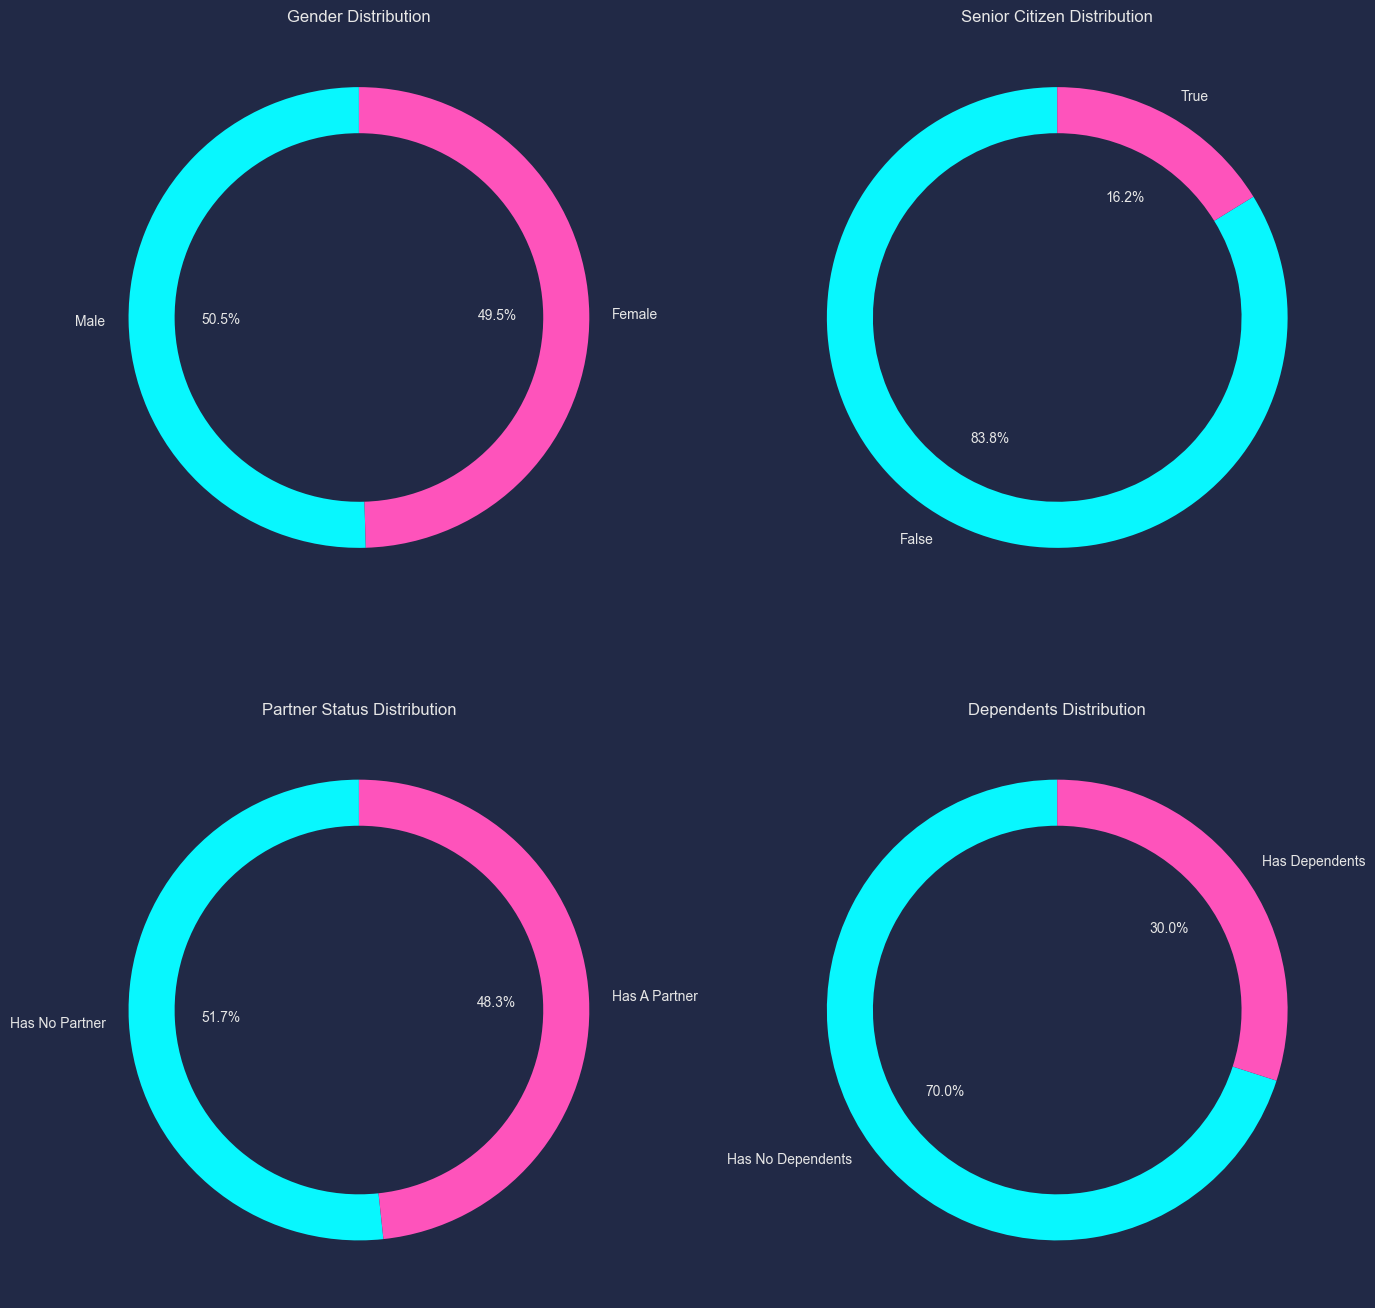

In [17]:

def pie_customer_desc(df):
    gender_count = df['gender'].value_counts().to_frame(name='Count')
    senior_citizen_count = df['is_senior_citizen'].value_counts().to_frame(
        name='Count')
    partners_count = df['has_partner'].value_counts().to_frame(name='Count')
    dependents_count = df['has_dependents'].value_counts().to_frame(
        name='Count')

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 14))

    # Pie chart for Gender Distribution
    ax1.pie(
        x=gender_count['Count'],
        labels=gender_count.index,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.2}
    )
    ax1.set_aspect('equal')
    ax1.set_title('Gender Distribution')

    # Pie chart for Senior Citizen Distribution
    ax2.pie(
        x=senior_citizen_count['Count'],
        labels=senior_citizen_count.index,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.2}
    )
    ax2.set_aspect('equal')
    ax2.set_title('Senior Citizen Distribution')

    # Pie chart for Partner Status Distribution
    ax3.pie(
        x=partners_count['Count'],
        labels=['Has No Partner', 'Has A Partner'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.2}
    )
    ax3.set_aspect('equal')
    ax3.set_title('Partner Status Distribution')

    # Pie chart for Dependents Distribution
    ax4.pie(
        x=dependents_count['Count'],
        labels=['Has No Dependents', 'Has Dependents'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.2}
    )
    ax4.set_aspect('equal')
    ax4.set_title('Dependents Distribution')

    plt.tight_layout()

    plt.show()


# Usage example with your DataFrame
pie_customer_desc(df_transformed)

## Service Usage


### Tenure Distribution


C:\Users\Joshua\AppData\Local\Temp\ipykernel_19360\1071536057.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_distribution = pd.concat(


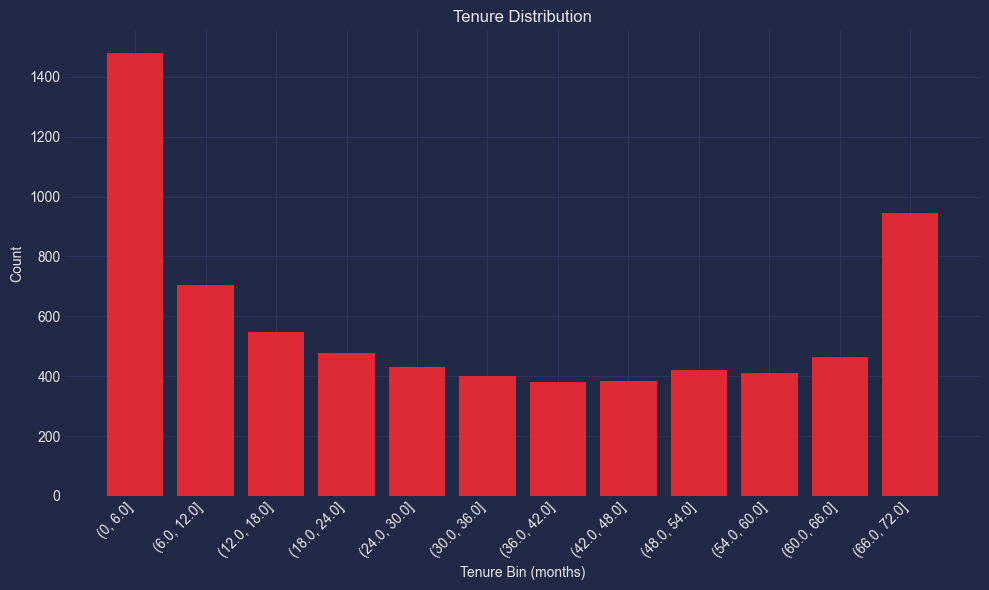

In [18]:
tenure_count = df_transformed['tenure'].value_counts(
).to_frame().sort_index().reset_index()

tenure_bin = pd.cut(tenure_count['tenure'], bins=12).to_frame()
tenure_bin.columns = ['bin']

tenure_distribution = pd.concat(
    [tenure_count, tenure_bin], axis=1).groupby(by='bin').sum().reset_index()[['bin', 'count']]
tenure_distribution['bin'] = tenure_distribution['bin'].astype(str)
tenure_distribution['bin'] = tenure_distribution['bin'].apply(
    lambda x: '(0, 6.0]' if x == '(-0.072, 6.0]' else x)

tenure_distribution.columns = ['Bin', 'Count']

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.bar(
    x=tenure_distribution['Bin'],
    height=tenure_distribution['Count'],
    color='#DF2935'
)
ax.set_title('Tenure Distribution')
ax.set_xlabel('Tenure Bin (months)')
ax.set_ylabel('Count')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [19]:
df_transformed['tenure_bin'] = pd.cut(
    df_transformed['tenure'], bins=12).to_frame()
df_transformed['tenure_bin'] = df_transformed['tenure_bin'].astype(str)
df_transformed['tenure_bin'] = df_transformed['tenure_bin'].apply(
    lambda x: '(0, 6.0]' if x == '(-0.072, 6.0]' else x)

In [20]:
count_series = df_transformed.groupby(by=['tenure_bin']).count()['customer_id']
normalized_counts = count_series / count_series.sum()

normalized_counts

tenure_bin
(0, 6.0]        0.210280
(12.0, 18.0]    0.077808
(18.0, 24.0]    0.067585
(24.0, 30.0]    0.061196
(30.0, 36.0]    0.056936
(36.0, 42.0]    0.053812
(42.0, 48.0]    0.054380
(48.0, 54.0]    0.059634
(54.0, 60.0]    0.058498
(6.0, 12.0]     0.100099
(60.0, 66.0]    0.065739
(66.0, 72.0]    0.134034
Name: customer_id, dtype: float64

### Internet and Phone Services


Text(0.5, 1.0, 'Phone Service Usage')

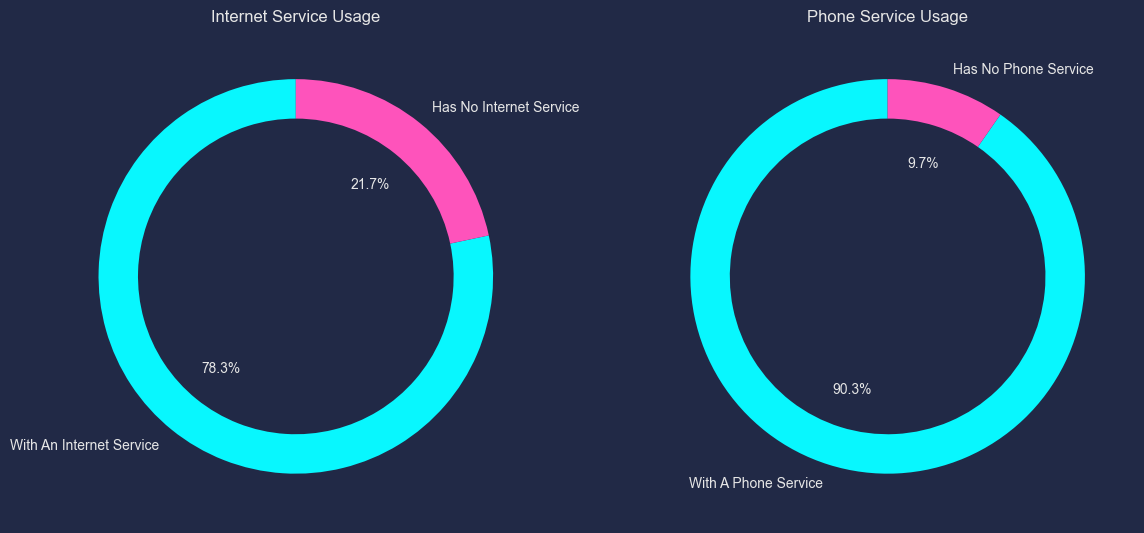

In [21]:
has_internet_count = df_transformed['has_internet_service'].value_counts(
).to_frame()
has_internet_count.columns = ['Count']

has_phone_count = df_transformed['has_phone_service'].value_counts().to_frame()
has_phone_count.columns = ['Count']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 14))
ax1.pie(
    x=has_internet_count['Count'],
    labels=['With An Internet Service', 'Has No Internet Service'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.2}
)
ax1.set_aspect('equal')
ax1.set_title('Internet Service Usage')

ax2.pie(
    x=has_phone_count['Count'],
    labels=['With A Phone Service', 'Has No Phone Service'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.2}
)
ax2.set_aspect('equal')
ax2.set_title('Phone Service Usage')

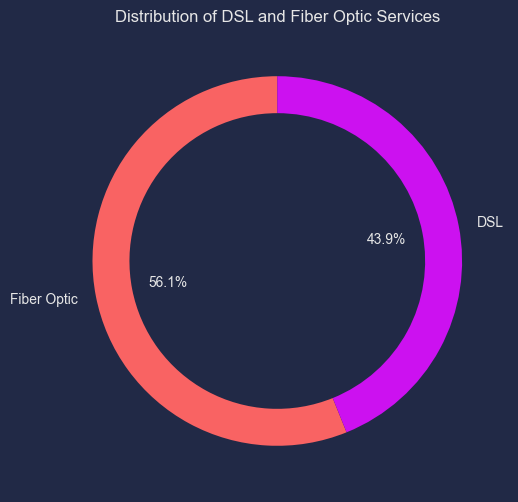

In [22]:
internet_service_distribution = df_transformed.groupby(by=['is_dsl', 'is_fiber_optic']).count().reset_index()[
    ['is_dsl', 'is_fiber_optic', 'customer_id']]

internet_service_distribution = internet_service_distribution[
    internet_service_distribution['is_dsl'] != internet_service_distribution['is_fiber_optic']]

labels = internet_service_distribution.apply(
    lambda row: 'DSL' if row['is_dsl'] else 'Fiber Optic', axis=1)
sizes = internet_service_distribution['customer_id']

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes,
       labels=labels,
       autopct='%1.1f%%',
       colors=['#f96363', '#cc11f0'],
       startangle=90,
       wedgeprops={'width': 0.2},)
plt.title('Distribution of DSL and Fiber Optic Services')

plt.show()

Text(75.58333333333333, 0.5, 'Has Internet Service')

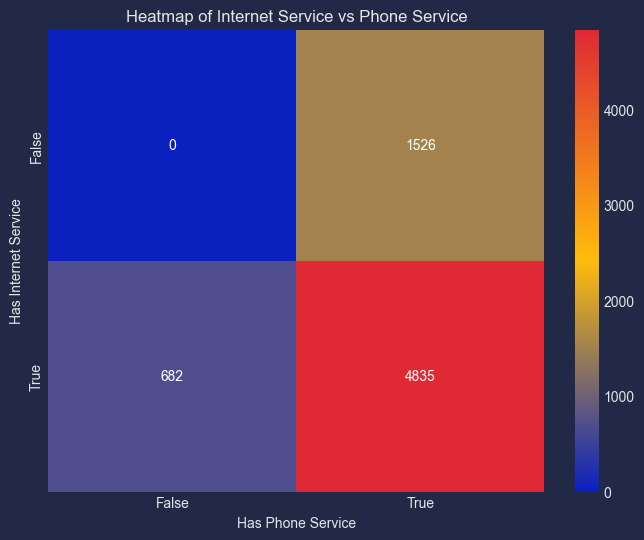

In [23]:
from matplotlib.colors import LinearSegmentedColormap

colors = ['#0A21C0', '#FFBC0A', '#DF2935']

custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)
internet_X_phone_distribution = pd.crosstab(df_transformed['has_internet_service'],
                                            df_transformed['has_phone_service'])


fig, ax = plt.subplots(figsize=(8, 6))


sns.heatmap(internet_X_phone_distribution, annot=True,

            cmap=custom_cmap, fmt='d', ax=ax)


ax.set_title('Heatmap of Internet Service vs Phone Service')

ax.set_xlabel('Has Phone Service')

ax.set_ylabel('Has Internet Service')

#### Internet Service Add-ons


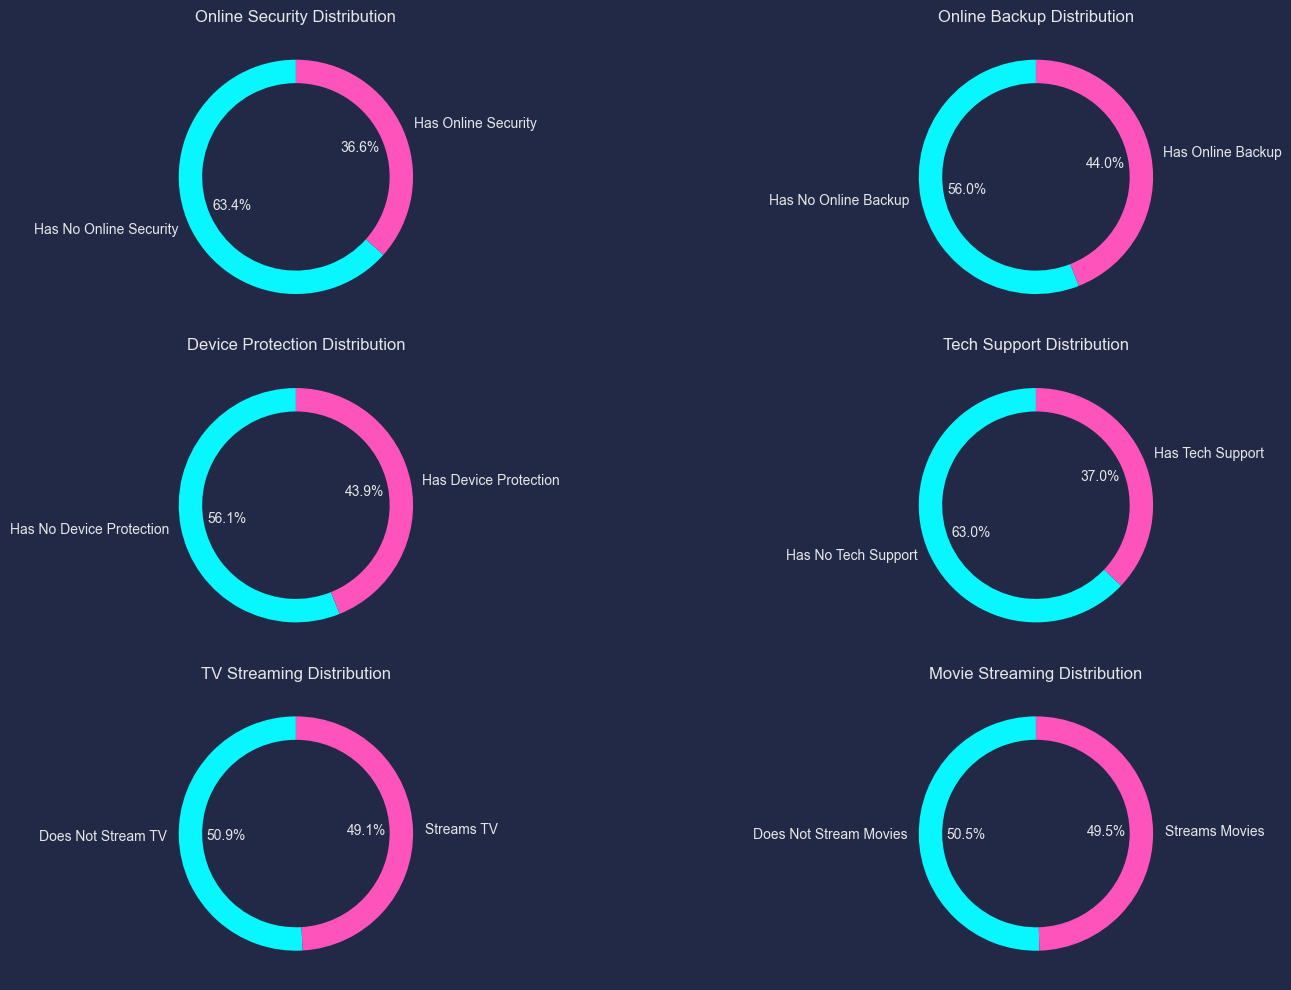

In [24]:
has_internet = df_transformed[df_transformed['has_internet_service'] == True]


def pie_customer_desc(df):
    # Calculate counts for each category
    has_online_security_count = df['has_online_security'].value_counts().to_frame(
        name='Count')
    has_online_backup_count = df['has_online_backup'].value_counts().to_frame(
        name='Count')
    has_device_protection_count = df['has_device_protection'].value_counts(
    ).to_frame(name='Count')
    has_tech_support_count = df['has_tech_support'].value_counts().to_frame(
        name='Count')
    has_streaming_tv_count = df['has_streaming_tv'].value_counts().to_frame(
        name='Count')
    has_streaming_movies_count = df['has_streaming_movies'].value_counts().to_frame(
        name='Count')

    fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(
        3, 2, figsize=(16, 10))

    # Pie chart for Online Security Distribution
    ax1.pie(
        x=has_online_security_count['Count'],
        labels=['Has No Online Security', 'Has Online Security'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.2}
    )
    ax1.set_aspect('equal')
    ax1.set_title('Online Security Distribution')

    # Pie chart for Online Backup Distribution
    ax2.pie(
        x=has_online_backup_count['Count'],
        labels=['Has No Online Backup', 'Has Online Backup'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.2}
    )
    ax2.set_aspect('equal')
    ax2.set_title('Online Backup Distribution')

    # Pie chart for Device Protection Distribution
    ax3.pie(
        x=has_device_protection_count['Count'],
        labels=['Has No Device Protection', 'Has Device Protection'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.2}
    )
    ax3.set_aspect('equal')
    ax3.set_title('Device Protection Distribution')

    # Pie chart for Tech Support Distribution
    ax4.pie(
        x=has_tech_support_count['Count'],
        labels=['Has No Tech Support', 'Has Tech Support'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.2}
    )
    ax4.set_aspect('equal')
    ax4.set_title('Tech Support Distribution')

    # Pie chart for TV Streaming Distribution
    ax5.pie(
        x=has_streaming_tv_count['Count'],
        labels=['Does Not Stream TV', 'Streams TV'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.2}
    )
    ax5.set_aspect('equal')
    ax5.set_title('TV Streaming Distribution')

    # Pie chart for Movie Streaming Distribution
    ax6.pie(
        x=has_streaming_movies_count['Count'],
        labels=['Does Not Stream Movies', 'Streams Movies'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.2}
    )
    ax6.set_aspect('equal')
    ax6.set_title('Movie Streaming Distribution')

    plt.tight_layout()

    plt.show()


# Usage example with your DataFrame
pie_customer_desc(has_internet)

In [79]:
bundle_count = df_transformed.groupby(
    by=['has_online_security',
        'has_online_backup',
        'has_device_protection',
        'has_tech_support',
        'has_streaming_tv',
        'has_streaming_movies']
).count()['customer_id'].to_frame().reset_index().sort_values(by='customer_id', ascending=False)

bundle_count['total'] = bundle_count['customer_id'].sum()
bundle_count['proportion'] = bundle_count['customer_id'] / \
    bundle_count['total']

bundle_count

,has_online_security,has_online_backup,has_device_protection,has_tech_support,has_streaming_tv,has_streaming_movies,customer_id,total,proportion
0,False,False,False,False,False,False,2219,7043,0.315065
63,True,True,True,True,True,True,284,7043,0.040324
3,False,False,False,False,True,True,218,7043,0.030953
16,False,True,False,False,False,False,209,7043,0.029675
27,False,True,True,False,True,True,196,7043,0.027829
...,...,...,...,...,...,...,...,...,...
41,True,False,True,False,False,True,27,7043,0.003834
46,True,False,True,True,True,False,25,7043,0.003550
38,True,False,False,True,True,False,25,7043,0.003550
42,True,False,True,False,True,False,23,7043,0.003266


### Churn Distribution


Text(0.5, 1.0, 'Churn Distribution')

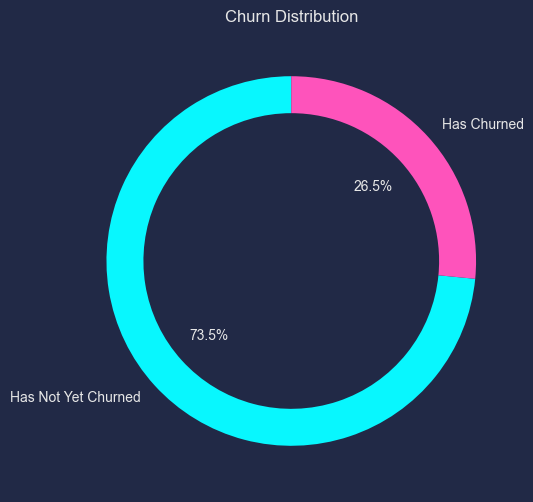

In [25]:
churn_count = df_transformed['churn'].value_counts().to_frame()
churn_count.columns = ['Count']

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    x=churn_count['Count'],
    labels=['Has Not Yet Churned', 'Has Churned'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.2}
)
ax.set_aspect('equal')
ax.set_title('Churn Distribution')

In [26]:
bin_X_charges = df_transformed[['tenure_bin', 'monthly_charges']]

bin_X_charges.groupby(by=['tenure_bin']).mean()[
    'monthly_charges']

tenure_bin
(0, 6.0]        54.738656
(12.0, 18.0]    61.236131
(18.0, 24.0]    61.496744
(24.0, 30.0]    63.929698
(30.0, 36.0]    67.344389
(36.0, 42.0]    65.610158
(42.0, 48.0]    67.018930
(48.0, 54.0]    70.039286
(54.0, 60.0]    71.072209
(6.0, 12.0]     58.952908
(60.0, 66.0]    75.335529
(66.0, 72.0]    76.255403
Name: monthly_charges, dtype: float64

In [27]:
has_churned = df_transformed[df_transformed['churn'] == True].copy()

has_churned['lcl'] = has_churned['tenure_bin'].apply(
    lambda x: float(x.split(',')[0].strip('(')))

churned_count_avg_mch = has_churned.groupby(by=['tenure_bin', 'lcl']).agg(
    customer_count=('customer_id', 'count'),
    avg_charges=('monthly_charges', 'mean')
).reset_index().sort_values(by='lcl')

# Churn Rate with respect to **Customer Demographics**


- How do different customer demographics (such as gender, being a senior citizen, partner status, and dependent status) affect churn rates?
- What demographic factors are most strongly associated with higher churn rates, and how can this information be used to tailor retention strategies?


#### Gender


In [28]:
def churn_rate(col, df):

    chrt_by_col = df.groupby(by=[f'{col}', 'churn']).count()[
        'customer_id'].to_frame().reset_index()

    chrt_by_col[f'total_by_{col}'] = chrt_by_col.groupby(
        by=[f'{col}'])['customer_id'].transform('sum')

    chrt_by_col['churn_rate'] = chrt_by_col['customer_id'] / \
        chrt_by_col[f'total_by_{col}']

    chrt_by_col = chrt_by_col[chrt_by_col['churn'] == True]

    return chrt_by_col


churn_rate('gender', df_transformed)

,gender,churn,customer_id,total_by_gender,churn_rate
1,Female,True,939,3488,0.269209
3,Male,True,930,3555,0.261603


#### Senior Citizen


In [29]:
def churn_rate(col, df):

    chrt_by_col = df.groupby(by=[f'{col}', 'churn']).count()[
        'customer_id'].to_frame().reset_index()

    chrt_by_col[f'total_by_{col}'] = chrt_by_col.groupby(
        by=[f'{col}'])['customer_id'].transform('sum')

    chrt_by_col['churn_rate'] = chrt_by_col['customer_id'] / \
        chrt_by_col[f'total_by_{col}']

    chrt_by_col = chrt_by_col[chrt_by_col['churn'] == True]

    return chrt_by_col


churn_rate('is_senior_citizen', df_transformed)

,is_senior_citizen,churn,customer_id,total_by_is_senior_citizen,churn_rate
1,False,True,1393,5901,0.236062
3,True,True,476,1142,0.416813


### Presence of Partners


In [30]:
def churn_rate(col, df):

    chrt_by_col = df.groupby(by=[f'{col}', 'churn']).count()[
        'customer_id'].to_frame().reset_index()

    chrt_by_col[f'total_by_{col}'] = chrt_by_col.groupby(
        by=[f'{col}'])['customer_id'].transform('sum')

    chrt_by_col['churn_rate'] = chrt_by_col['customer_id'] / \
        chrt_by_col[f'total_by_{col}']

    chrt_by_col = chrt_by_col[chrt_by_col['churn'] == True]

    return chrt_by_col


churn_rate('has_partner', df_transformed)

,has_partner,churn,customer_id,total_by_has_partner,churn_rate
1,False,True,1200,3641,0.329580
3,True,True,669,3402,0.196649


### Presence of Dependents


In [31]:
def churn_rate(col, df):

    chrt_by_col = df.groupby(by=[f'{col}', 'churn']).count()[
        'customer_id'].to_frame().reset_index()

    chrt_by_col[f'total_by_{col}'] = chrt_by_col.groupby(
        by=[f'{col}'])['customer_id'].transform('sum')

    chrt_by_col['churn_rate'] = chrt_by_col['customer_id'] / \
        chrt_by_col[f'total_by_{col}']

    chrt_by_col = chrt_by_col[chrt_by_col['churn'] == True]

    return chrt_by_col


churn_rate('has_dependents', df_transformed)

,has_dependents,churn,customer_id,total_by_has_dependents,churn_rate
1,False,True,1543,4933,0.312791
3,True,True,326,2110,0.154502


# Tenure Analysis


- How does the length of time a customer has been with the company influence their likelihood to churn?
- What patterns are observed in churn rates for customers in their first year versus those who have been with the company longer?
- How can targeted retention strategies be developed based on tenure to reduce churn during critical periods?


In [32]:
def churn_rate(col, df):

    chrt_by_col = df.groupby(by=[f'{col}', 'churn']).count()[
        'customer_id'].to_frame().reset_index()

    chrt_by_col[f'total_by_{col}'] = chrt_by_col.groupby(
        by=[f'{col}'])['customer_id'].transform('sum')

    chrt_by_col['churn_rate'] = chrt_by_col['customer_id'] / \
        chrt_by_col[f'total_by_{col}']

    chrt_by_col = chrt_by_col[chrt_by_col['churn'] == True]

    return chrt_by_col


chrt_tenure = churn_rate('tenure_bin', df_transformed)


def extract_first_number(bin_label):
    match = re.match(r'\(([\d.]+),', bin_label)
    if match:
        return float(match.group(1))
    return None


chrt_tenure['lcb'] = chrt_tenure['tenure_bin'].apply(extract_first_number)
chrt_tenure = chrt_tenure.sort_values(by=['lcb'])[['tenure_bin', 'churn_rate']]

chrt_tenure.columns = ['Bin', 'Churn Rate']

chrt_tenure

,Bin,Churn Rate
1,"(0, 6.0]",0.529372
19,"(6.0, 12.0]",0.358865
3,"(12.0, 18.0]",0.322993
5,"(18.0, 24.0]",0.245798
7,"(24.0, 30.0]",0.218097
9,"(30.0, 36.0]",0.214464
11,"(36.0, 42.0]",0.218997
13,"(42.0, 48.0]",0.161880
15,"(48.0, 54.0]",0.161905
17,"(54.0, 60.0]",0.126214


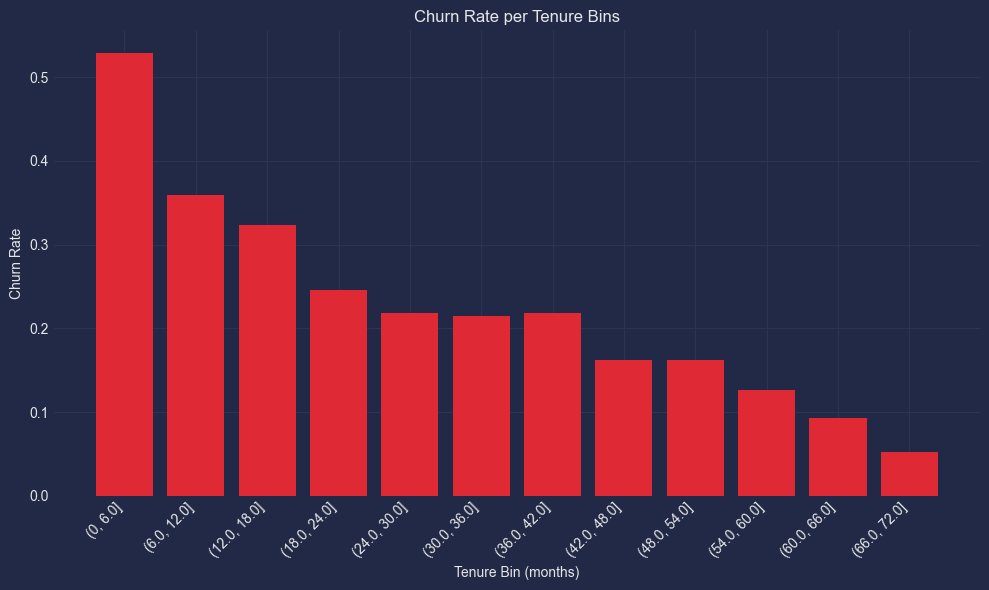

In [33]:
def churn_rate(col, df):

    chrt_by_col = df.groupby(by=[f'{col}', 'churn']).count()[
        'customer_id'].to_frame().reset_index()

    chrt_by_col[f'total_by_{col}'] = chrt_by_col.groupby(
        by=[f'{col}'])['customer_id'].transform('sum')

    chrt_by_col['churn_rate'] = chrt_by_col['customer_id'] / \
        chrt_by_col[f'total_by_{col}']

    chrt_by_col = chrt_by_col[chrt_by_col['churn'] == True]

    return chrt_by_col


chrt_tenure = churn_rate('tenure_bin', df_transformed)


def extract_first_number(bin_label):
    match = re.match(r'\(([\d.]+),', bin_label)
    if match:
        return float(match.group(1))
    return None


chrt_tenure['lcb'] = chrt_tenure['tenure_bin'].apply(extract_first_number)
chrt_tenure = chrt_tenure.sort_values(by=['lcb'])[['tenure_bin', 'churn_rate']]

chrt_tenure.columns = ['Bin', 'Churn Rate']

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.bar(
    x=chrt_tenure['Bin'],
    height=chrt_tenure['Churn Rate'],
    color='#DF2935'
)
ax.set_title('Churn Rate per Tenure Bins')
ax.set_xlabel('Tenure Bin (months)')
ax.set_ylabel('Churn Rate')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [34]:
tenure_X_churn = df_transformed[['tenure', 'churn']].copy()


def corr_churn_X_continuous(df, continuous_col):
    df['churn'] = df['churn'].astype(int)

    correlation, p_value = stats.pointbiserialr(df['churn'],
                                                df[continuous_col])
    return correlation, p_value


correlation, p_value = corr_churn_X_continuous(
    tenure_X_churn, 'tenure')
print(f"Correlation: {correlation}, P-value: {p_value}")

Correlation: -0.352228670113078, P-value: 7.999057960588301e-205


# Service, Bundling, and Churn


## Internet and Phone Services


In [35]:
chrt_by_service = df_transformed.groupby(by=['has_internet_service', 'has_phone_service', 'churn']).count()[
    'customer_id'].to_frame().reset_index()

chrt_by_service['total'] = chrt_by_service.groupby(
    by=['has_internet_service', 'has_phone_service'])['customer_id'].transform('sum')

chrt_by_service['churn_rate'] = chrt_by_service['customer_id'] / \
    chrt_by_service['total']

chrt_by_service = chrt_by_service[chrt_by_service['churn'] == True]

chrt_by_service

,has_internet_service,has_phone_service,churn,customer_id,total,churn_rate
1,False,True,True,113,1526,0.074050
3,True,False,True,170,682,0.249267
5,True,True,True,1586,4835,0.328025


In [36]:
charges_X_services = df_transformed[[
    'has_internet_service', 'has_phone_service', 'churn', 'monthly_charges']]
avg_charges_by_service_X_churn = charges_X_services.groupby(
    by=['has_internet_service', 'has_phone_service', 'churn']).mean().reset_index()
avg_charges_by_service_X_churn[avg_charges_by_service_X_churn['churn'] == True]

,has_internet_service,has_phone_service,churn,monthly_charges
1,False,True,True,20.368142
3,True,False,True,37.533824
5,True,True,True,82.250000


## Internet Service Type


In [37]:
chrt_by_internet = df_transformed.groupby(by=['is_dsl', 'is_fiber_optic', 'churn']).count()[
    'customer_id'].to_frame().reset_index()

chrt_by_internet['total'] = chrt_by_internet.groupby(
    by=['is_dsl', 'is_fiber_optic'])['customer_id'].transform('sum')

chrt_by_internet['churn_rate'] = chrt_by_internet['customer_id'] / \
    chrt_by_internet['total']

chrt_by_internet = chrt_by_internet[(chrt_by_internet['churn'] == True) & (
    chrt_by_internet['is_dsl'] != chrt_by_internet['is_fiber_optic'])]

chrt_by_internet

,is_dsl,is_fiber_optic,churn,customer_id,total,churn_rate
3,False,True,True,1297,3096,0.418928
5,True,False,True,459,2421,0.189591


## Internet Service Add-ons


In [71]:
chrt_by_bundle_combi = df_transformed.groupby(
    by=['has_online_security',
        'has_online_backup',
        'has_device_protection',
        'has_tech_support',
        'has_streaming_tv',
        'has_streaming_movies',
        'churn']
).count()['customer_id'].to_frame().reset_index()

chrt_by_bundle_combi['total'] = chrt_by_bundle_combi.groupby(
    by=['has_online_security',
        'has_online_backup',
        'has_device_protection',
        'has_tech_support',
        'has_streaming_tv',
        'has_streaming_movies']
)['customer_id'].transform('sum')

chrt_by_bundle_combi['churn_rate'] = chrt_by_bundle_combi['customer_id'] / \
    chrt_by_bundle_combi['total']

chrt_by_bundle_combi = chrt_by_bundle_combi[chrt_by_bundle_combi['churn'] == True]

chrt_by_bundle_combi.sort_values(
    by=['churn_rate'], ascending=False).head(5)

,has_online_security,has_online_backup,has_device_protection,has_tech_support,has_streaming_tv,has_streaming_movies,churn,customer_id,total,churn_rate
3,False,False,False,False,False,True,True,120,185,0.648649
5,False,False,False,False,True,False,True,105,171,0.614035
7,False,False,False,False,True,True,True,131,218,0.600917
23,False,False,True,False,True,True,True,96,189,0.507937
39,False,True,False,False,True,True,True,58,127,0.456693


In [38]:
has_internet = df_transformed[df_transformed['is_dsl'] == True]

chrt_by_bundle_combi = has_internet.groupby(by=['is_dsl',
                                                'has_online_security',
                                                'has_online_backup',
                                                'has_device_protection',
                                                'has_tech_support',
                                                'has_streaming_tv',
                                                'has_streaming_movies',
                                                'churn']).count()[
    'customer_id'].to_frame().reset_index()

chrt_by_bundle_combi['total'] = chrt_by_bundle_combi.groupby(
    by=[
        'has_online_security',
        'has_online_backup',
        'has_device_protection',
        'has_tech_support',
        'has_streaming_tv',
        'has_streaming_movies'])['customer_id'].transform('sum')

chrt_by_bundle_combi['churn_rate'] = chrt_by_bundle_combi['customer_id'] / \
    chrt_by_bundle_combi['total']

chrt_by_bundle_combi = chrt_by_bundle_combi[chrt_by_bundle_combi['churn'] == True]

chrt_by_bundle_combi.sort_values(by=['churn_rate'], ascending=False).head(5)

,is_dsl,has_online_security,has_online_backup,has_device_protection,has_tech_support,has_streaming_tv,has_streaming_movies,churn,customer_id,total,churn_rate
3,True,False,False,False,False,False,True,True,25,47,0.531915
5,True,False,False,False,False,True,False,True,18,41,0.439024
17,True,False,False,True,False,False,False,True,21,50,0.420000
1,True,False,False,False,False,False,False,True,121,294,0.411565
7,True,False,False,False,False,True,True,True,15,37,0.405405


In [39]:
has_internet = df_transformed[df_transformed['is_fiber_optic'] == True]

chrt_by_bundle_combi = has_internet.groupby(by=['is_fiber_optic',
                                                'has_online_security',
                                                'has_online_backup',
                                                'has_device_protection',
                                                'has_tech_support',
                                                'has_streaming_tv',
                                                'has_streaming_movies',
                                                'churn']).count()[
    'customer_id'].to_frame().reset_index()

chrt_by_bundle_combi['total'] = chrt_by_bundle_combi.groupby(
    by=[
        'has_online_security',
        'has_online_backup',
        'has_device_protection',
        'has_tech_support',
        'has_streaming_tv',
        'has_streaming_movies'])['customer_id'].transform('sum')

chrt_by_bundle_combi['churn_rate'] = chrt_by_bundle_combi['customer_id'] / \
    chrt_by_bundle_combi['total']

chrt_by_bundle_combi = chrt_by_bundle_combi[chrt_by_bundle_combi['churn'] == True]

chrt_by_bundle_combi.sort_values(by=['churn_rate'], ascending=False)

,is_fiber_optic,has_online_security,has_online_backup,has_device_protection,has_tech_support,has_streaming_tv,has_streaming_movies,churn,customer_id,total,churn_rate
3,True,False,False,False,False,False,True,True,95,138,0.688406
5,True,False,False,False,False,True,False,True,87,130,0.669231
7,True,False,False,False,False,True,True,True,116,181,0.640884
13,True,False,False,False,True,True,False,True,11,18,0.611111
1,True,False,False,False,False,False,False,True,241,399,0.604010
...,...,...,...,...,...,...,...,...,...,...,...
114,True,True,True,True,False,False,True,True,1,15,0.066667
124,True,True,True,True,True,True,False,True,1,15,0.066667
104,True,True,True,False,True,False,False,True,1,16,0.062500
122,True,True,True,True,True,False,True,True,1,17,0.058824


# Charges Analysis


## Contract Type


In [40]:
chrt_by_contract = df_transformed.groupby(by=['has_monthly_contract', 'has_one_year_contract', 'has_two_year_contract', 'churn']).count()[
    'customer_id'].to_frame().reset_index()

chrt_by_contract['total'] = chrt_by_contract.groupby(
    by=['has_monthly_contract', 'has_one_year_contract', 'has_two_year_contract'])['customer_id'].transform('sum')

chrt_by_contract['churn_rate'] = chrt_by_contract['customer_id'] / \
    chrt_by_contract['total']

chrt_by_contract = chrt_by_contract[(chrt_by_contract['churn'] == True)]

chrt_by_contract

,has_monthly_contract,has_one_year_contract,has_two_year_contract,churn,customer_id,total,churn_rate
1,False,False,True,True,48,1695,0.028319
3,False,True,False,True,166,1473,0.112695
5,True,False,False,True,1655,3875,0.427097


Text(0.5, 1.0, 'Contract Distribution')

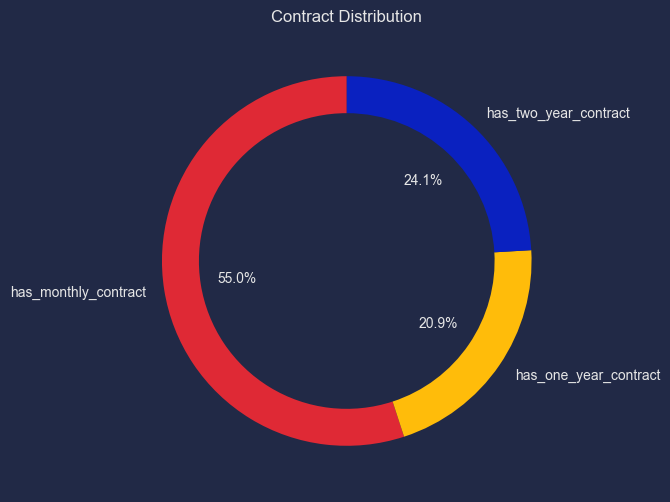

In [41]:
ctr_count = df_transformed.groupby(by=['has_monthly_contract', 'has_one_year_contract', 'has_two_year_contract']).count()[
    'customer_id'].to_frame().reset_index()

ctr_count_long = pd.melt(ctr_count, id_vars=['customer_id'],
                         value_vars=[
                             'has_monthly_contract', 'has_one_year_contract', 'has_two_year_contract'],
                         var_name='contract_type',
                         value_name='has_contract')
ctr_count_long = ctr_count_long[ctr_count_long['has_contract'] == True][[
    'contract_type', 'customer_id']]
ctr_count_long.columns = ['Contract Type', 'Count']

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    x=ctr_count_long['Count'],
    labels=ctr_count_long['Contract Type'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.2},
    colors=['#DF2935', '#FFBC0A', '#0A21C0']
)
ax.set_aspect('equal')
ax.set_title('Contract Distribution')

## Payment Method


In [42]:
chrt_by_paym = df_transformed.groupby(by=['is_bank_transfer', 'is_credit_card', 'is_electronic_check', 'is_mailed_check', 'churn']).count()[
    'customer_id'].to_frame().reset_index()

chrt_by_paym['total'] = chrt_by_paym.groupby(
    by=['is_bank_transfer', 'is_credit_card', 'is_electronic_check', 'is_mailed_check'])['customer_id'].transform('sum')

chrt_by_paym['churn_rate'] = chrt_by_paym['customer_id'] / \
    chrt_by_paym['total']

chrt_by_paym = chrt_by_paym[(chrt_by_paym['churn'] == True)]

chrt_by_paym

,is_bank_transfer,is_credit_card,is_electronic_check,is_mailed_check,churn,customer_id,total,churn_rate
1,False,False,False,True,True,308,1612,0.191067
3,False,False,True,False,True,1071,2365,0.452854
5,False,True,False,False,True,232,1522,0.152431
7,True,False,False,False,True,258,1544,0.167098


## Monthly Charges


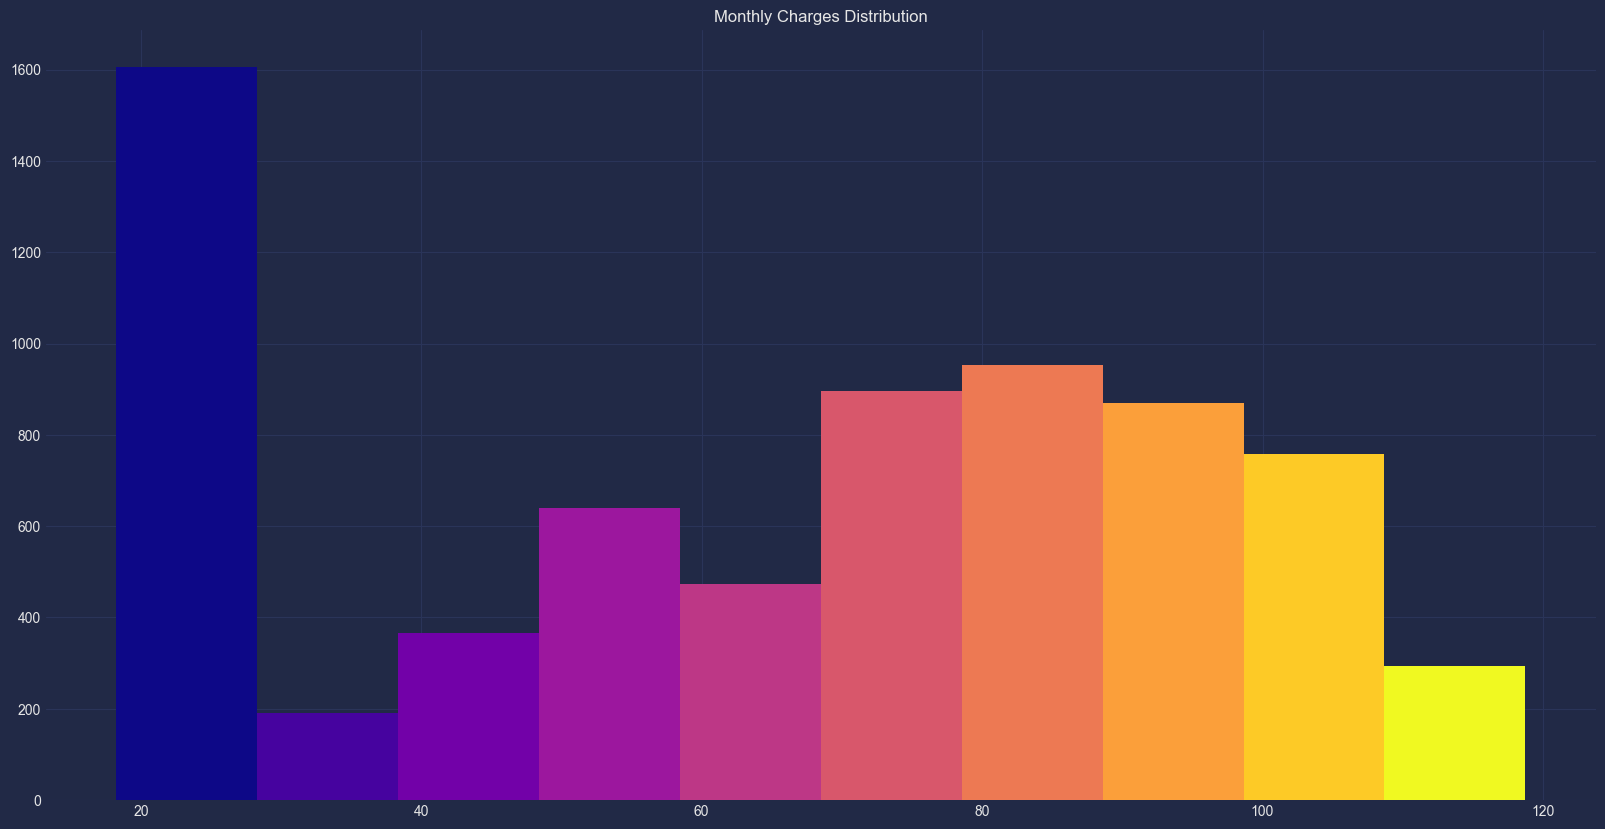

In [43]:
monthly_charges = df_transformed['monthly_charges']

fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# Create the histogram
n, bins, patches = ax.hist(x=monthly_charges)

# Apply a colormap (e.g., 'plasma') for a gradient effect
cmap = plt.get_cmap('plasma')

bin_centers = 0.5 * (bins[:-1] + bins[1:])
col = (bin_centers - min(bin_centers)) / (max(bin_centers) - min(bin_centers))

for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cmap(c))

ax.set_title('Monthly Charges Distribution')

mplcyberpunk.add_glow_effects()

plt.show()

In [44]:
monthly_charges_X_churn = df_transformed[['monthly_charges', 'churn']].copy()


def corr_churn_X_continuous(df, continuous_col):
    df['churn'] = df['churn'].astype(int)

    correlation, p_value = stats.pointbiserialr(df['churn'],
                                                df[continuous_col])
    return correlation, p_value


correlation, p_value = corr_churn_X_continuous(
    monthly_charges_X_churn, 'monthly_charges')
print(f"Correlation: {correlation}, P-value: {p_value}")

Correlation: 0.19335642223784702, P-value: 2.706645606888227e-60


# Correlations across **Binary Attributes**


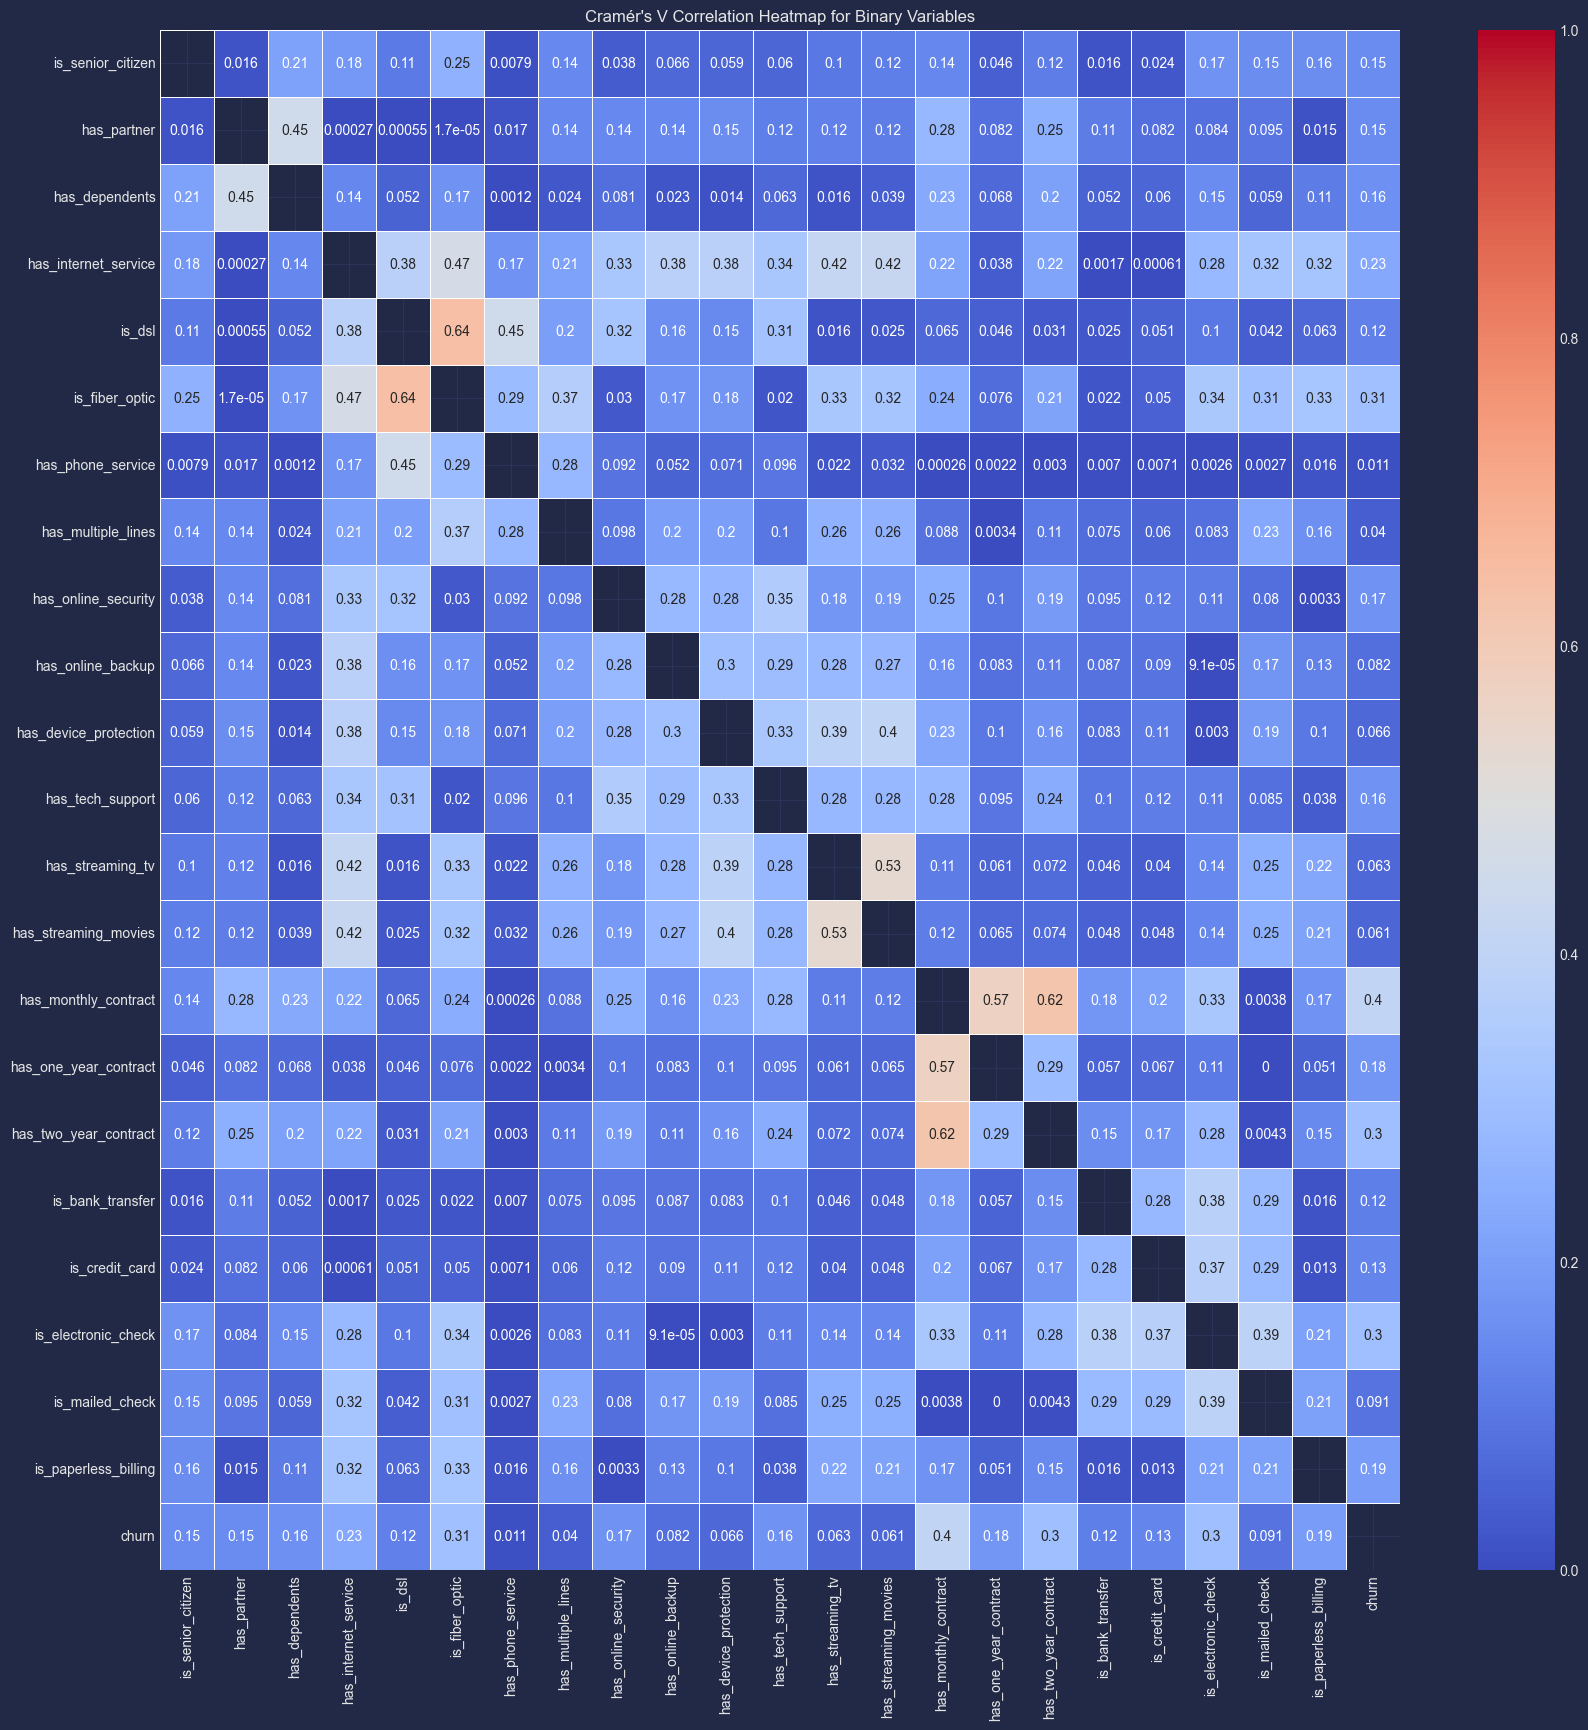

In [45]:
binary_cols = [
    'is_senior_citizen', 'has_partner', 'has_dependents', 'has_internet_service',
    'is_dsl', 'is_fiber_optic', 'has_phone_service', 'has_multiple_lines',
    'has_online_security', 'has_online_backup', 'has_device_protection',
    'has_tech_support', 'has_streaming_tv', 'has_streaming_movies',
    'has_monthly_contract', 'has_one_year_contract', 'has_two_year_contract',
    'is_bank_transfer', 'is_credit_card', 'is_electronic_check',
    'is_mailed_check', 'is_paperless_billing', 'churn'
]

df_binary = df_transformed[binary_cols].astype(int)


def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = sum(confusion_matrix.sum())
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))


# Create a DataFrame to store the Cramér's V values
cramers_v_matrix = pd.DataFrame(
    index=df_binary.columns, columns=df_binary.columns)

# Calculate Cramér's V for each pair of binary columns
for col1 in df_binary.columns:
    for col2 in df_binary.columns:
        if col1 != col2:
            cramers_v_matrix.loc[col1, col2] = cramers_v(
                df_binary[col1], df_binary[col2])
        else:
            # Set diagonal to NaN or 0
            cramers_v_matrix.loc[col1, col2] = np.nan

cramers_v_matrix = cramers_v_matrix.astype(float)

# Plot the heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(cramers_v_matrix, annot=True, cmap='coolwarm',
            vmin=0, vmax=1, linewidths=.5)
plt.title("Cramér's V Correlation Heatmap for Binary Variables")
plt.show()

# Predictive Analysis


## Preprocessing


In [57]:
df_encoded = pd.get_dummies(df_transformed,
                            columns=[
                                'gender'
                            ],
                            drop_first=True
                            )
df_encoded = df_encoded.drop(['customer_id', 'tenure_bin'], axis=1)
df_encoded = df_encoded.rename(columns={'gender_Male': 'is_male'})

In [58]:
df_encoded

,is_senior_citizen,has_partner,has_dependents,tenure,has_internet_service,is_dsl,is_fiber_optic,has_phone_service,has_multiple_lines,has_online_security,has_online_backup,has_device_protection,has_tech_support,has_streaming_tv,has_streaming_movies,has_monthly_contract,has_one_year_contract,has_two_year_contract,is_bank_transfer,is_credit_card,is_electronic_check,is_mailed_check,is_paperless_billing,monthly_charges,total_charges,churn,is_male
0,False,True,False,1,True,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,True,29.85,29.85,False,False
1,False,False,False,34,True,True,False,True,False,True,False,True,False,False,False,False,True,False,False,False,False,True,False,56.95,1889.50,False,True
2,False,False,False,2,True,True,False,True,False,True,True,False,False,False,False,True,False,False,False,False,False,True,True,53.85,108.15,True,True
3,False,False,False,45,True,True,False,False,False,True,False,True,True,False,False,False,True,False,True,False,False,False,False,42.30,1840.75,False,True
4,False,False,False,2,True,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,70.70,151.65,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,True,True,24,True,True,False,True,True,True,False,True,True,True,True,False,True,False,False,False,False,True,True,84.80,1990.50,False,True
7039,False,True,True,72,True,False,True,True,True,False,True,True,False,True,True,False,True,False,False,True,False,False,True,103.20,7362.90,False,False
7040,False,True,True,11,True,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,True,29.60,346.45,False,False
7041,True,True,False,4,True,False,True,True,True,False,False,False,False,False,False,True,False,False,False,False,False,True,True,74.40,306.60,True,True


In [59]:
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

In [60]:
df_encoded

,is_senior_citizen,has_partner,has_dependents,tenure,has_internet_service,is_dsl,is_fiber_optic,has_phone_service,has_multiple_lines,has_online_security,has_online_backup,has_device_protection,has_tech_support,has_streaming_tv,has_streaming_movies,has_monthly_contract,has_one_year_contract,has_two_year_contract,is_bank_transfer,is_credit_card,is_electronic_check,is_mailed_check,is_paperless_billing,monthly_charges,total_charges,churn,is_male
0,0,1,0,1,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,29.85,29.85,0,0
1,0,0,0,34,1,1,0,1,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,56.95,1889.50,0,1
2,0,0,0,2,1,1,0,1,0,1,1,0,0,0,0,1,0,0,0,0,0,1,1,53.85,108.15,1,1
3,0,0,0,45,1,1,0,0,0,1,0,1,1,0,0,0,1,0,1,0,0,0,0,42.30,1840.75,0,1
4,0,0,0,2,1,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,70.70,151.65,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,1,0,1,1,1,0,1,1,1,1,0,1,0,0,0,0,1,1,84.80,1990.50,0,1
7039,0,1,1,72,1,0,1,1,1,0,1,1,0,1,1,0,1,0,0,1,0,0,1,103.20,7362.90,0,0
7040,0,1,1,11,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,29.60,346.45,0,0
7041,1,1,0,4,1,0,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,1,74.40,306.60,1,1


In [61]:
scaler = MinMaxScaler()
scaled_array = scaler.fit_transform(df_encoded)
df_scaled = pd.DataFrame(scaled_array, columns=df_encoded.columns)

In [62]:
# Prepare data
X = df_scaled.drop(columns='churn')
y = df_scaled['churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## Logistic Regression


In [63]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8218594748048261
              precision    recall  f1-score   support

         0.0       0.86      0.90      0.88      1036
         1.0       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



## Random Forest Classifier


In [64]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7913413768630234
              precision    recall  f1-score   support

         0.0       0.82      0.91      0.87      1036
         1.0       0.65      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



## Gradient Boosting


In [65]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize and fit model
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

# Predictions and evaluation
y_pred = gb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8105039034776437
              precision    recall  f1-score   support

         0.0       0.85      0.91      0.88      1036
         1.0       0.68      0.54      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [66]:
# Define hyperparameters to search
param_grid = {
    'penalty': ['l1', 'l2'],  # Regularization type
    'C': [0.001, 0.01, 0.1, 1, 10],  # Inverse of regularization strength
    'solver': ['liblinear', 'saga']  # Solver to use
}

# Set up Grid Search
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring='accuracy',  # or other metrics like 'precision', 'recall', etc.
    cv=5,  # Number of cross-validation folds
    verbose=1,  # Show progress
    n_jobs=-1  # Use all available cores
)

# Fit Grid Search
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

# Evaluate the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Accuracy on Test Data:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Score: 0.8020950321591297
Accuracy on Test Data: 0.8254080908445706
Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.91      0.88      1036
         1.0       0.70      0.59      0.64       373

    accuracy                           0.83      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.83      0.82      1409



In [67]:
importance = best_model.coef_[0]
feature_importance = pd.Series(
    importance, index=X.columns).sort_values(ascending=False)
print(feature_importance)

is_fiber_optic           0.908327
has_internet_service     0.555373
is_electronic_check      0.344270
is_paperless_billing     0.284060
has_streaming_movies     0.283714
has_multiple_lines       0.207960
has_streaming_tv         0.182437
is_senior_citizen        0.120118
has_partner              0.000000
is_dsl                   0.000000
total_charges            0.000000
monthly_charges          0.000000
has_monthly_contract     0.000000
has_device_protection    0.000000
is_bank_transfer         0.000000
is_mailed_check          0.000000
is_male                 -0.026310
is_credit_card          -0.026568
has_online_backup       -0.079407
has_dependents          -0.140604
has_tech_support        -0.269123
has_online_security     -0.357396
has_phone_service       -0.507359
has_one_year_contract   -0.607338
has_two_year_contract   -1.270343
tenure                  -2.204876
dtype: float64


# Others


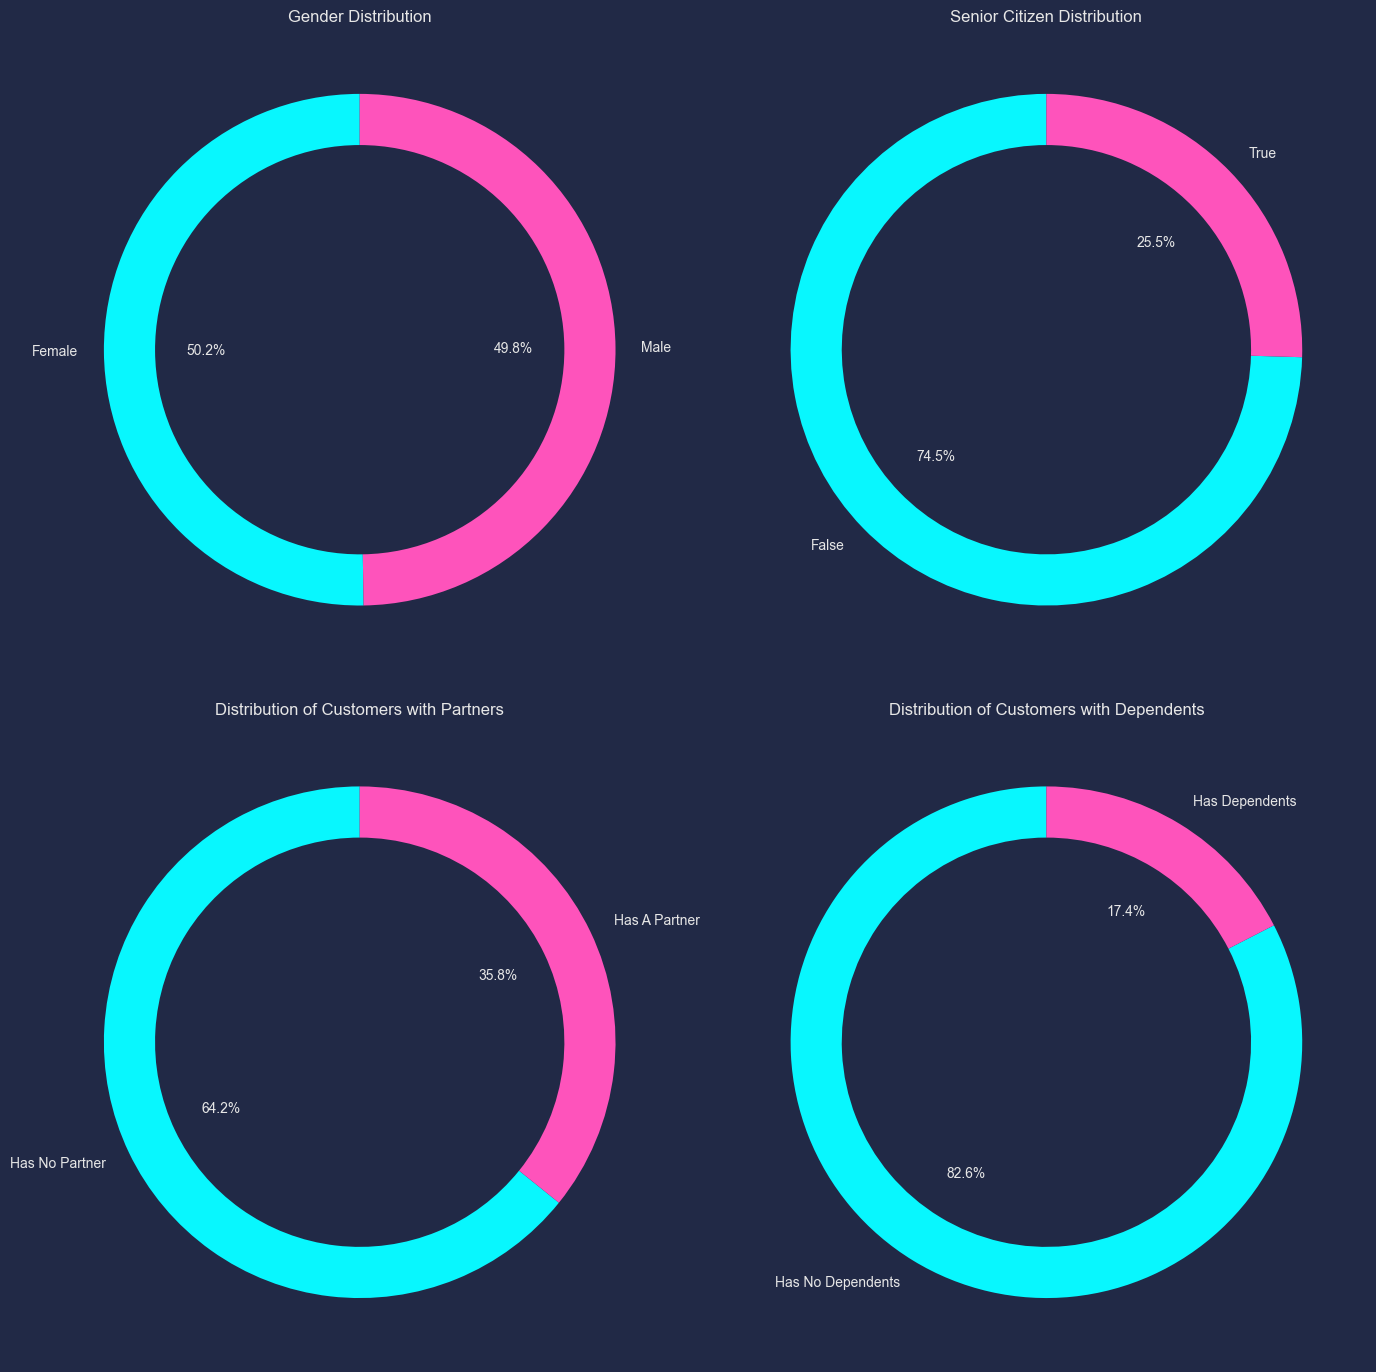

In [68]:
df_churned = df_transformed[df_transformed['churn'] == True]


def pie_customer_desc(df):

    # Calculate counts for each category

    gender_count = df['gender'].value_counts().to_frame(name='Count')

    senior_citizen_count = df['is_senior_citizen'].value_counts().to_frame(

        name='Count')

    partners_count = df['has_partner'].value_counts().to_frame(name='Count')

    dependents_count = df['has_dependents'].value_counts().to_frame(

        name='Count')

    # Create subplots

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 14))

    # Pie chart for Gender Distribution

    ax1.pie(

        x=gender_count['Count'],

        labels=gender_count.index,

        autopct='%1.1f%%',

        startangle=90,

        wedgeprops={'width': 0.2}
    )

    ax1.set_aspect('equal')

    ax1.set_title('Gender Distribution')

    # Pie chart for Senior Citizen Distribution

    ax2.pie(

        x=senior_citizen_count['Count'],

        labels=senior_citizen_count.index,

        autopct='%1.1f%%',

        startangle=90,

        wedgeprops={'width': 0.2}
    )

    ax2.set_aspect('equal')

    ax2.set_title('Senior Citizen Distribution')

    # Pie chart for Distribution of Customers with Partners

    ax3.pie(

        x=partners_count['Count'],

        labels=['Has No Partner', 'Has A Partner'],

        autopct='%1.1f%%',

        startangle=90,

        wedgeprops={'width': 0.2}
    )

    ax3.set_aspect('equal')

    ax3.set_title('Distribution of Customers with Partners')

    # Pie chart for Distribution of Customers with Dependents

    ax4.pie(

        x=dependents_count['Count'],

        labels=['Has No Dependents', 'Has Dependents'],

        autopct='%1.1f%%',

        startangle=90,

        wedgeprops={'width': 0.2}
    )

    ax4.set_aspect('equal')

    ax4.set_title('Distribution of Customers with Dependents')

    # Adjust layout to avoid overlap

    plt.tight_layout()

    # Show the plot

    plt.show()


# Usage example with your DataFrame

pie_customer_desc(df_churned)

In [69]:
df_transformed.groupby(by=['gender', 'is_senior_citizen',
                       'has_partner', 'has_dependents']).sum()['churn']

gender  is_senior_citizen  has_partner  has_dependents
Female  False              False        False             429
                                        True               32
                           True         False             114
                                        True              124
        True               False        False             158
                                        True                1
                           True         False              73
                                        True                8
Male    False              False        False             418
                                        True               43
                           True         False             128
                                        True              105
        True               False        False             118
                                        True                1
                           True         False             105
               